In [12]:
import pandas as pd
import os

# Define the path - make sure the filename matches exactly what you downloaded
csv_path = r"F:\candidate-joining-prediction-python\data\hr_data.csv"

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    
    print("1. Basic Information")
    print(df.info())
    
    print("\n2. Missing Values Check")
    print(df.isnull().sum())
    
    print("\n3. First 5 Rows ---")
    
    print(df.head().T) 
else:
    print(f"Error: Could not find the file at {csv_path}. Check your folder!")

1. Basic Information
<class 'pandas.DataFrame'>
RangeIndex: 8995 entries, 0 to 8994
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   SLNO                         8995 non-null   int64  
 1   Candidate Ref                8995 non-null   int64  
 2   DOJ Extended                 8995 non-null   str    
 3   Duration to accept offer     8995 non-null   int64  
 4   Notice period                8995 non-null   int64  
 5   Offered band                 8995 non-null   str    
 6   Pecent hike expected in CTC  8995 non-null   float64
 7   Percent hike offered in CTC  8995 non-null   float64
 8   Percent difference CTC       8995 non-null   float64
 9   Joining Bonus                8995 non-null   str    
 10  Candidate relocate actual    8995 non-null   str    
 11  Gender                       8995 non-null   str    
 12  Candidate Source             8995 non-null   str    
 13  Rex in Y

In [13]:
# 1. Check Class Balance (Joined vs Not Joined)
print("--- 1. Target Variable Balance ---")
print(df['Status'].value_counts(normalize=True) * 100)

# 2. Investigate the "Relocate Actual" column for Leakage
# We check: Did anyone "Actually Relocate" but "Not Join"? 
print("\n--- 2. Leakage Check: Relocate Actual vs Status ---")
print(pd.crosstab(df['Candidate relocate actual'], df['Status']))

# 3. Convert Target to Numeric (Joined = 1, Not Joined = 0)
# This makes it easier for the model to process later
df['target'] = df['Status'].apply(lambda x: 1 if x == 'Joined' else 0)

# 4. Clean the unnecessary ID columns
# We keep 'Candidate relocate actual' for now to see the results of Step 2
cols_to_drop = ['SLNO', 'Candidate Ref']
df_clean = df.drop(columns=cols_to_drop)

print("\n--- 3. Cleaned Data Preview ---")
print(df_clean.head())

--- 1. Target Variable Balance ---
Status
Joined        81.300723
Not Joined    18.699277
Name: proportion, dtype: float64

--- 2. Leakage Check: Relocate Actual vs Status ---
Status                     Joined  Not Joined
Candidate relocate actual                    
No                           6023        1682
Yes                          1290           0

--- 3. Cleaned Data Preview ---
  DOJ Extended  Duration to accept offer  Notice period Offered band  \
0          Yes                        14             30           E2   
1           No                        18             30           E2   
2           No                         3             45           E2   
3           No                        26             30           E2   
4          Yes                         1            120           E2   

   Pecent hike expected in CTC  Percent hike offered in CTC  \
0                       -20.79                        13.16   
1                        50.00                  

--- 1. Notice Period Joining Rates (%) ---
Notice period
0      93.436293
30     85.168670
45     75.475285
60     73.219373
75     68.181818
90     66.188198
120    52.380952
Name: target, dtype: float64

--- 2. Source Joining Rates (%) ---
Candidate Source
Agency               75.822050
Direct               82.003749
Employee Referral    88.004972
Name: target, dtype: float64

--- 3. Salary Hike Statistics (Mean/Median) ---
             mean  median        std
target                              
0       38.588460  34.945  31.904401
1       41.133205  36.360  36.940232

--- 4. Age Statistics ---
         count       mean       std   min   25%   50%   75%   max
target                                                           
0       1682.0  29.517836  3.923417  20.0  26.0  29.0  33.0  60.0
1       7313.0  30.004102  4.131917  20.0  27.0  30.0  34.0  50.0

--- 5. Average Days to Accept Offer (Joiners vs Non-Joiners) ---
target
0    24.956599
1    20.624368
Name: Duration to accept off

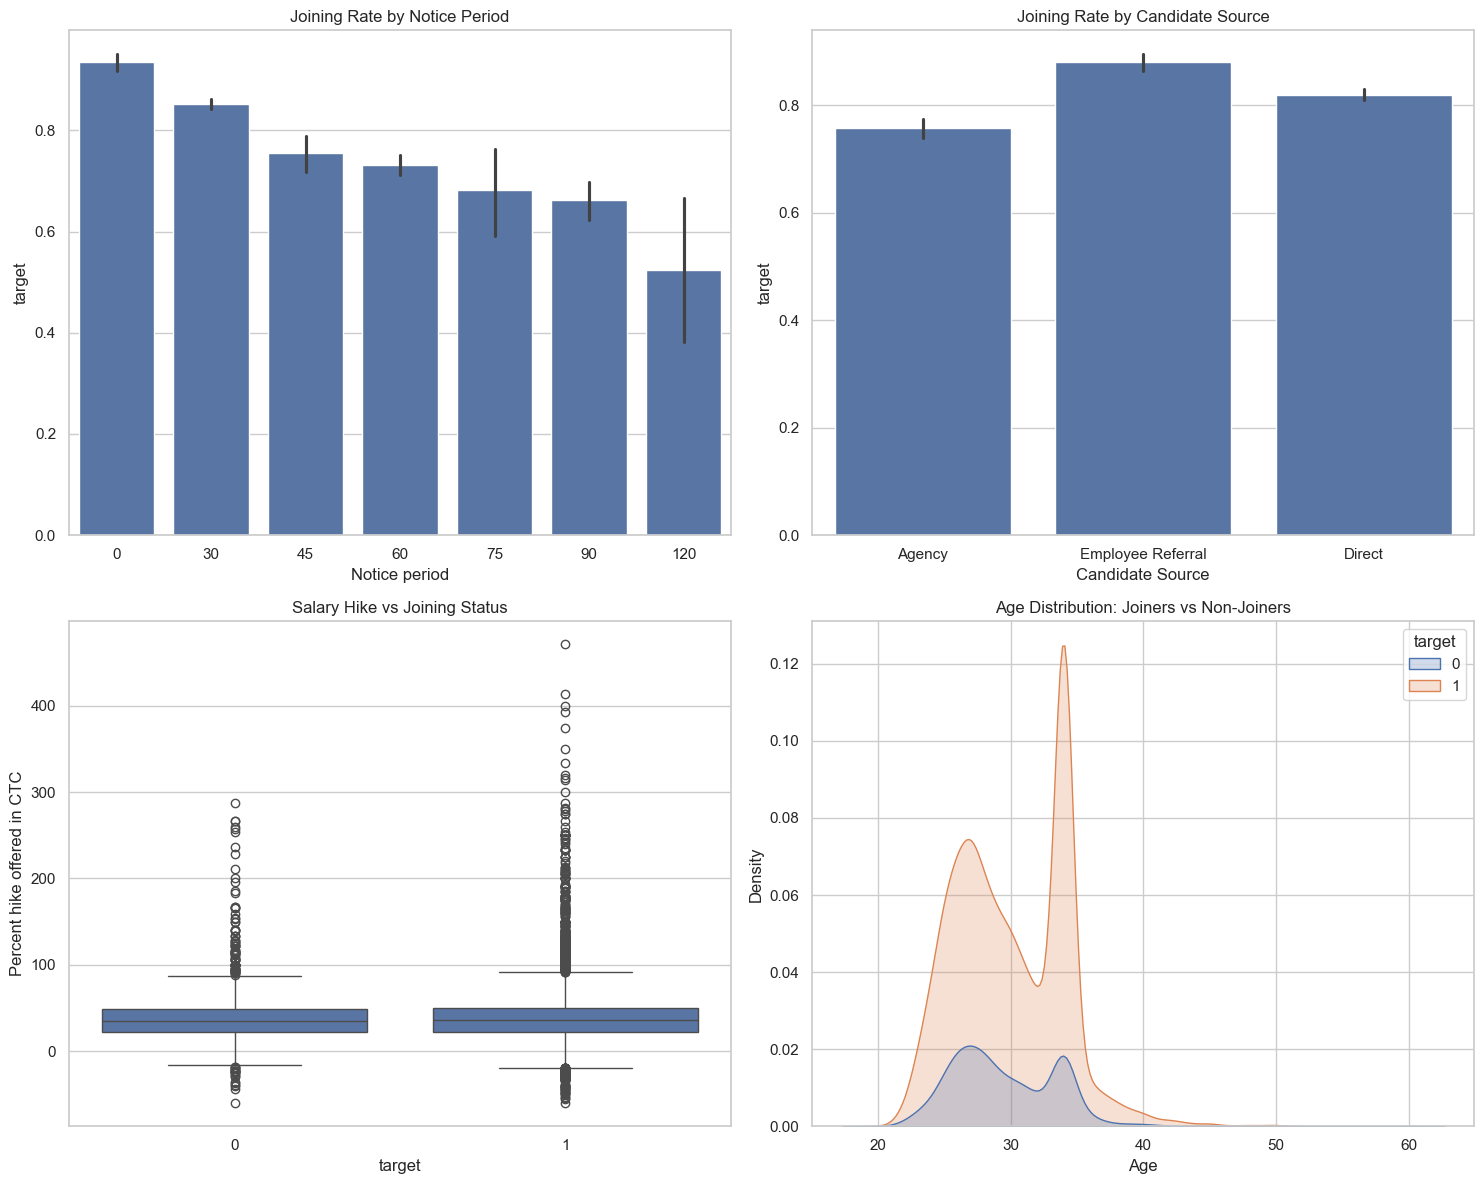

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Final Cleaning - dropping the leakage column and the text target
df_final = df_clean.drop(columns=['Candidate relocate actual', 'Status'])

# Set the style
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# --- Insight 1: Notice Period ---
sns.barplot(x='Notice period', y='target', data=df_final, ax=axes[0,0])
axes[0,0].set_title('Joining Rate by Notice Period')
print("--- 1. Notice Period Joining Rates (%) ---")
print(df_final.groupby('Notice period')['target'].mean() * 100)

# --- Insight 2: Candidate Source ---
sns.barplot(x='Candidate Source', y='target', data=df_final, ax=axes[0,1])
axes[0,1].set_title('Joining Rate by Candidate Source')
print("\n--- 2. Source Joining Rates (%) ---")
print(df_final.groupby('Candidate Source')['target'].mean() * 100)

# --- Insight 3: Salary Hike ---
sns.boxplot(x='target', y='Percent hike offered in CTC', data=df_final, ax=axes[1,0])
axes[1,0].set_title('Salary Hike vs Joining Status')
print("\n--- 3. Salary Hike Statistics (Mean/Median) ---")
print(df_final.groupby('target')['Percent hike offered in CTC'].agg(['mean', 'median', 'std']))

# --- Insight 4: Age ---
sns.kdeplot(data=df_final, x="Age", hue="target", fill=True, ax=axes[1,1])
axes[1,1].set_title('Age Distribution: Joiners vs Non-Joiners')
print("\n--- 4. Age Statistics ---")
print(df_final.groupby('target')['Age'].describe())

# --- Insight 5: Duration to Accept vs Target ---
print("\n--- 5. Average Days to Accept Offer (Joiners vs Non-Joiners) ---")
print(df_final.groupby('target')['Duration to accept offer'].mean())

plt.tight_layout()
plt.show() # This will show the charts directly if you are in a notebook

Target column found?  True
Shape of X: (8995, 13)
--- LOGISTIC REGRESSION (Balanced) ---
              precision    recall  f1-score   support

           0       0.28      0.63      0.39       336
           1       0.88      0.63      0.73      1463

    accuracy                           0.63      1799
   macro avg       0.58      0.63      0.56      1799
weighted avg       0.77      0.63      0.67      1799


--- NAIVE BAYES (Legacy Comparison) ---
              precision    recall  f1-score   support

           0       0.19      0.99      0.32       336
           1       0.96      0.03      0.06      1463

    accuracy                           0.21      1799
   macro avg       0.57      0.51      0.19      1799
weighted avg       0.81      0.21      0.11      1799



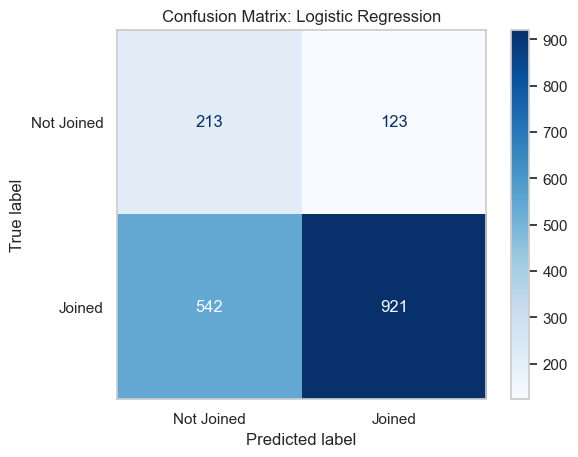

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- 1. Feature Engineering (Using df_clean as the base) ---
# Create the features first
df_clean['hike_gap'] = df_clean['Percent hike offered in CTC'] - df_clean['Pecent hike expected in CTC']
df_clean['is_fast_joiner'] = (df_clean['Notice period'] <= 30).astype(int)
df_clean['is_hesitant'] = (df_clean['Duration to accept offer'] > 21).astype(int)

# Now define df_final by dropping only what we don't need for the model
# We KEEP 'target' here so we can use it for y
df_final = df_clean.drop(columns=['Candidate relocate actual', 'Status'])

# --- 2. Defining Features and Target ---
categorical_features = ['DOJ Extended', 'Offered band', 'Gender', 'Candidate Source', 'LOB', 'Location']
numeric_features = ['Duration to accept offer', 'Notice period', 'Rex in Yrs', 'Age', 'hike_gap', 'is_fast_joiner', 'is_hesitant']

X = df_final[categorical_features + numeric_features]
y = df_final['target']  # This should work now!

print("Target column found? ", 'target' in df_final.columns)
print("Shape of X:", X.shape)

# --- 3. Preprocessing Pipeline ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# --- 4. Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- 5. Model Training (Logistic Regression with Class Weights) ---
# We use class_weight='balanced' to handle the 81/19 imbalance ChatGPT mentioned
model_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42))
])

model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

# --- 6. Model Training (Naive Bayes) ---
# Transform the data
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Handle the 'toarray' issue dynamically
if hasattr(X_train_transformed, "toarray"):
    X_train_dense = X_train_transformed.toarray()
    X_test_dense = X_test_transformed.toarray()
else:
    X_train_dense = X_train_transformed
    X_test_dense = X_test_transformed

model_nb_core = GaussianNB()
model_nb_core.fit(X_train_dense, y_train)
y_pred_nb = model_nb_core.predict(X_test_dense)

# --- 7. Evaluation ---
print("--- LOGISTIC REGRESSION (Balanced) ---")
print(classification_report(y_test, y_pred_lr))

print("\n--- NAIVE BAYES (Legacy Comparison) ---")
print(classification_report(y_test, y_pred_nb))

# Plot Confusion Matrix for Logistic Regression
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, display_labels=['Not Joined', 'Joined'], cmap='Blues')
plt.title("Confusion Matrix: Logistic Regression")
plt.grid(False)
plt.show()

In [16]:
# Extract the coefficients from the Logistic Regression
import numpy as np

# Get feature names from the OneHotEncoder
cat_feature_names = model_lr.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numeric_features, cat_feature_names])

# Get coefficients
coefficients = model_lr.named_steps['classifier'].coef_[0]

# Create a DataFrame for visualization
importance_df = pd.DataFrame({'Feature': all_feature_names, 'Coefficient': coefficients})
importance_df['Abs_Coefficient'] = importance_df['Coefficient'].abs()
importance_df = importance_df.sort_values(by='Abs_Coefficient', ascending=False)

print("--- Top 10 Most Influential Features ---")
print(importance_df[['Feature', 'Coefficient']].head(10))

--- Top 10 Most Influential Features ---
                    Feature  Coefficient
26                  LOB_MMS     1.019829
36          Location_Others     1.003654
9           Offered band_E0    -0.905248
27       Location_Ahmedabad    -0.711447
21                  LOB_EAS    -0.621911
30          Location_Cochin    -0.502791
12          Offered band_E3     0.424928
35           Location_Noida     0.378970
18                 LOB_AXON    -0.375114
15  Candidate Source_Agency    -0.367736
